In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



## Import

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Read CSV file

In [5]:
df = pd.read_csv(r'/Users/himanshupaithane/Downloads/NFT_Top_Collections.csv')

##### Split Table into 2 tables. (USD and SOLONA)

In [6]:
nft = df[['Index', 'Name', 'Volume', 'Market_Cap', 'Sales', 'Floor_Price', 'Average_Price', 'Owners', 'Assets', 'Owner_Asset_Ratio', 'Category', 'Website', 'Logo']]
nft_usd = df[['Index', 'Name', 'Volume_USD', 'Market_Cap_USD', 'Sales', 'Floor_Price_USD', 'Average_Price_USD', 'Owners', 'Assets', 'Owner_Asset_Ratio', 'Category', 'Website', 'Logo']]

## Data Describing

In [7]:
nft.shape

(592, 13)

In [8]:
nft.columns

Index(['Index', 'Name', 'Volume', 'Market_Cap', 'Sales', 'Floor_Price',
       'Average_Price', 'Owners', 'Assets', 'Owner_Asset_Ratio', 'Category',
       'Website', 'Logo'],
      dtype='object')

In [9]:
nft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 592 entries, 0 to 591
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Index              592 non-null    int64  
 1   Name               592 non-null    object 
 2   Volume             592 non-null    float64
 3   Market_Cap         592 non-null    float64
 4   Sales              592 non-null    int64  
 5   Floor_Price        544 non-null    float64
 6   Average_Price      592 non-null    float64
 7   Owners             592 non-null    int64  
 8   Assets             592 non-null    int64  
 9   Owner_Asset_Ratio  543 non-null    float64
 10  Category           310 non-null    object 
 11  Website            481 non-null    object 
 12  Logo               591 non-null    object 
dtypes: float64(5), int64(4), object(4)
memory usage: 60.2+ KB


In [10]:
nft.describe()

,Index,Volume,Market_Cap,Sales,Floor_Price,Average_Price,Owners,Assets,Owner_Asset_Ratio
count,592.000000,592.000000,592.000000,592.000000,544.000000,592.000000,592.000000,592.000000,543.000000
mean,296.547297,197.548885,45.134817,164.491554,2.423015,2.373566,53.731419,116.694257,54.385672
std,172.520622,1283.031435,179.327166,451.321395,18.982148,15.035229,133.893752,251.598765,27.632770
min,0.000000,0.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000,0.260000
25%,147.750000,7.300000,0.000000,11.000000,0.110000,0.306029,4.000000,10.000000,33.330000
50%,295.500000,18.595000,0.000000,35.000000,0.300000,0.720412,15.000000,38.000000,57.250000
75%,444.250000,80.825000,21.841974,107.250000,1.000000,1.596750,44.000000,102.250000,72.845000
max,599.000000,27256.630000,2530.877143,5229.000000,400.000000,347.500000,2041.000000,3320.000000,100.000000


## Data Wrangling

In [11]:
count_missing = pd.DataFrame({
    'Missing Values' : nft.isna().sum(),
    'Percentage' : nft.isna().sum()/len(nft)*100
})
count_missing

,Missing Values,Percentage
Index,0,0.000000
Name,0,0.000000
Volume,0,0.000000
Market_Cap,0,0.000000
Sales,0,0.000000
Floor_Price,48,8.108108
Average_Price,0,0.000000
Owners,0,0.000000
Assets,0,0.000000
Owner_Asset_Ratio,49,8.277027


#### Drop Unnecessary Features

In [12]:
try:
    nft.drop(columns = ["Category","Website","Logo"], inplace = True)
    print('Drop successfully')
except:
    print("You're already drop thoses features")

Drop successfully


/Applications/anaconda3/lib/python3.8/site-packages/pandas/core/frame.py:4163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


#### Drop Missing Values

In [13]:
nft.dropna(inplace=True)

<ipython-input-13-5958131e12d5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nft.dropna(inplace=True)


#### Drop Duplicate Values

In [14]:
nft[nft.duplicated()]

,Index,Name,Volume,Market_Cap,Sales,Floor_Price,Average_Price,Owners,Assets,Owner_Asset_Ratio


There are no missing values.

## Exploratory Data Analysis

#### Top10: Volume

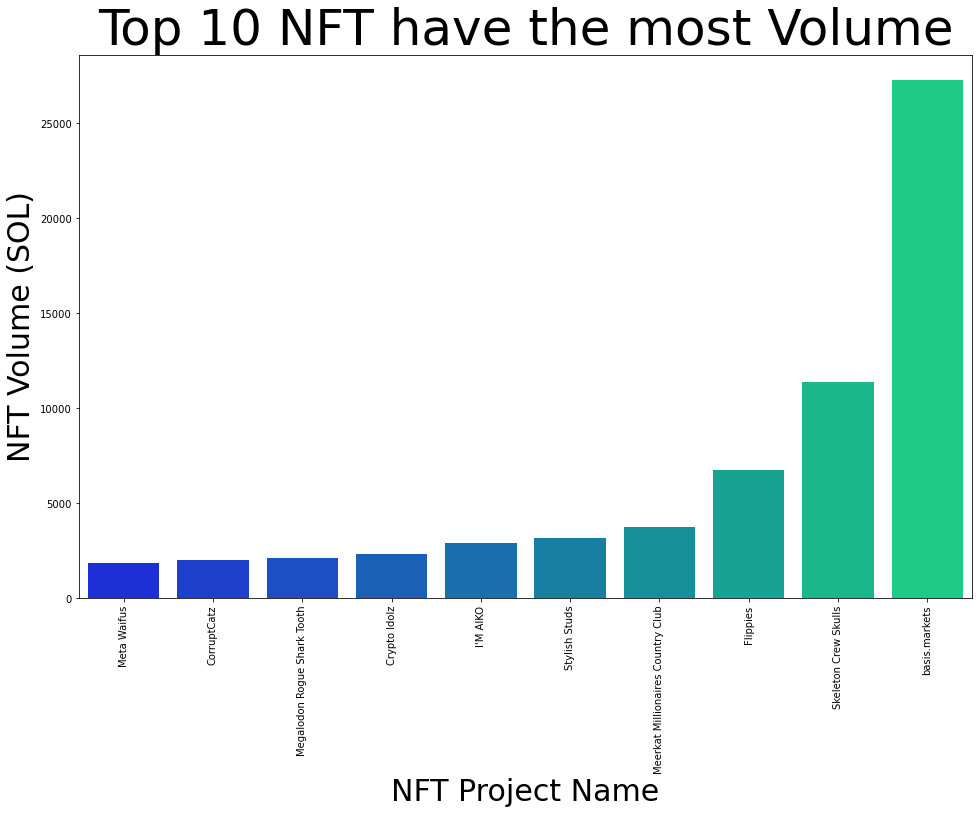

,Index,Name,Volume,Market_Cap,Sales,Floor_Price,Average_Price,Owners,Assets,Owner_Asset_Ratio
0,0,basis.markets,27256.63,708.145455,366,39.50,74.471667,12,16,75.00
1,1,Skeleton Crew Skulls,11381.25,106.656000,2075,0.67,5.484940,103,132,78.03
2,2,Flippies,6732.19,1663.863158,1504,0.80,4.476190,905,1638,55.25
3,3,Meerkat Millionaires Country Club,3734.76,90.275000,395,3.79,9.455089,19,23,82.61
4,4,Stylish Studs,3191.15,165.000000,729,4.30,4.377435,28,50,56.00
5,5,I'M AIKO,2904.70,2530.877143,1411,1.20,2.058611,599,1206,49.67
6,6,Crypto Idolz,2315.74,1168.041981,1418,0.60,1.633103,244,529,46.12
7,7,Megalodon Rogue Shark Tooth,2116.61,60.050375,5229,0.04,0.404783,946,1309,72.27
8,8,CorruptCatz,1983.92,345.790000,1489,0.10,1.332384,636,916,69.43
9,9,Meta Waifus,1844.59,989.491267,1156,1.27,1.595666,376,643,58.48


In [15]:
top_volume = nft.head(10).sort_values(by='Volume')
plt.subplots(figsize=(16,10))
sns.barplot(x=top_volume.Name,y=top_volume.Volume,palette = "winter")
plt.xticks(rotation = 90)
plt.xlabel("NFT Project Name",fontsize =30)
plt.ylabel("NFT Volume (SOL)",fontsize =30)
plt.title("Top 10 NFT have the most Volume",fontsize =50)
plt.show()

display(nft.sort_values(by='Volume', ascending=False).head(10))

#### Top10: Market Cap

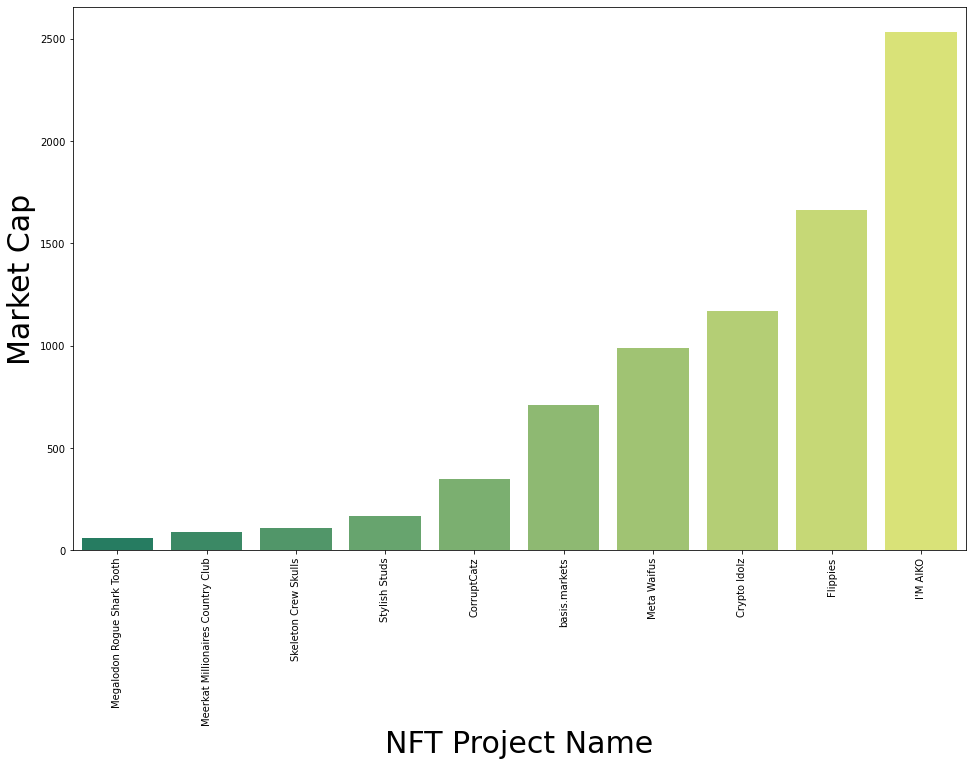

,Index,Name,Volume,Market_Cap,Sales,Floor_Price,Average_Price,Owners,Assets,Owner_Asset_Ratio
5,5,I'M AIKO,2904.70,2530.877143,1411,1.20,2.058611,599,1206,49.67
2,2,Flippies,6732.19,1663.863158,1504,0.80,4.476190,905,1638,55.25
43,43,CoinCards (Solana),422.44,1368.147826,506,0.30,0.834862,56,860,6.51
6,6,Crypto Idolz,2315.74,1168.041981,1418,0.60,1.633103,244,529,46.12
9,9,Meta Waifus,1844.59,989.491267,1156,1.27,1.595666,376,643,58.48
15,15,Crypto Idolz - Faces,990.64,962.156774,1264,0.25,0.783734,388,1239,31.32
34,34,MyRareFrog (Solana),518.81,936.992857,579,0.85,0.896045,15,466,3.22
10,10,Crypto Idolz - Butts,1756.29,910.915461,2906,0.24,0.604367,413,847,48.76
0,0,basis.markets,27256.63,708.145455,366,39.50,74.471667,12,16,75.00
29,29,SOL NFL Player's,643.51,624.494063,411,0.25,1.565718,304,451,67.41


In [16]:
top_marketcap = nft.head(10).sort_values(by='Market_Cap')
plt.subplots(figsize=(16,10))
sns.barplot(x=top_marketcap.Name, y=top_marketcap.Market_Cap, palette='summer')
plt.xticks(rotation=90)
plt.xlabel("NFT Project Name",fontsize =30)
plt.ylabel("Market Cap", fontsize=30)
plt.show()

display(nft.sort_values(by='Market_Cap', ascending=False).head(10))

#### Top10: Sales

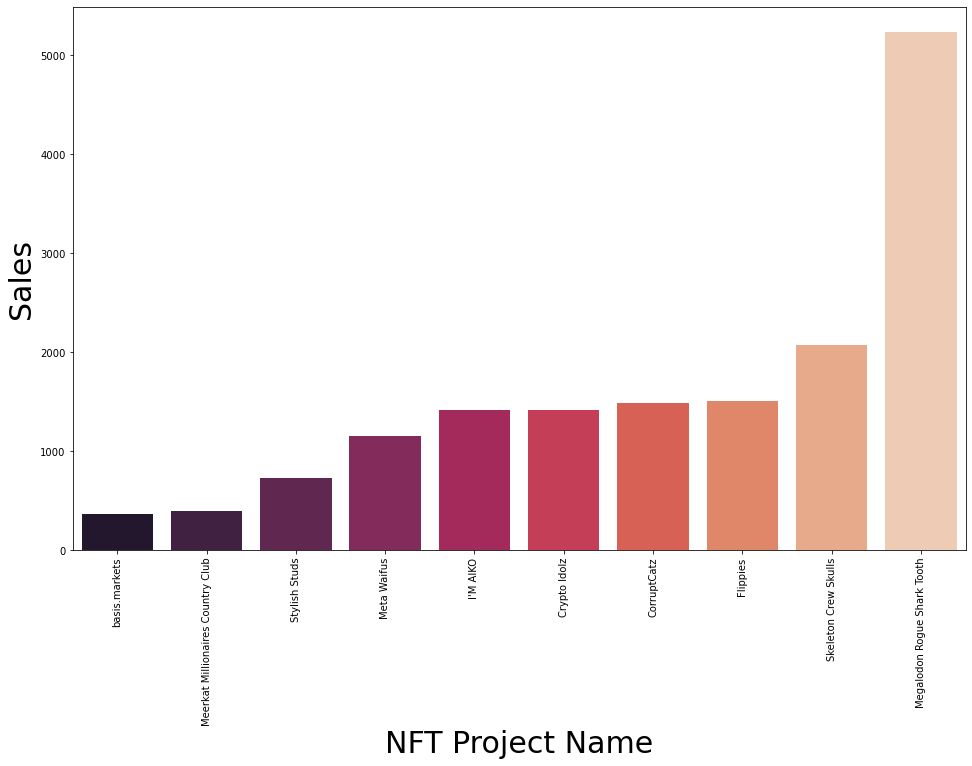

,Index,Name,Volume,Market_Cap,Sales,Floor_Price,Average_Price,Owners,Assets,Owner_Asset_Ratio
7,7,Megalodon Rogue Shark Tooth,2116.61,60.050375,5229,0.04,0.404783,946,1309,72.27
1,1,Skeleton Crew Skulls,11381.25,106.656000,2075,0.67,5.484940,103,132,78.03
2,2,Flippies,6732.19,1663.863158,1504,0.80,4.476190,905,1638,55.25
8,8,CorruptCatz,1983.92,345.790000,1489,0.10,1.332384,636,916,69.43
6,6,Crypto Idolz,2315.74,1168.041981,1418,0.60,1.633103,244,529,46.12
5,5,I'M AIKO,2904.70,2530.877143,1411,1.20,2.058611,599,1206,49.67
9,9,Meta Waifus,1844.59,989.491267,1156,1.27,1.595666,376,643,58.48
4,4,Stylish Studs,3191.15,165.000000,729,4.30,4.377435,28,50,56.00
3,3,Meerkat Millionaires Country Club,3734.76,90.275000,395,3.79,9.455089,19,23,82.61
0,0,basis.markets,27256.63,708.145455,366,39.50,74.471667,12,16,75.00


In [17]:
top_sale = nft.head(10).sort_values(by='Sales')
plt.subplots(figsize =(16,10))
sns.barplot(x=top_sale.Name, y=top_sale.Sales, palette='rocket')
plt.xticks(rotation=90)
plt.ylabel('Sales', fontsize=30)
plt.xlabel('NFT Project Name', fontsize=30)
plt.show()
display(nft.head(10).sort_values(by='Sales', ascending=False))

#### Top10: Average Price

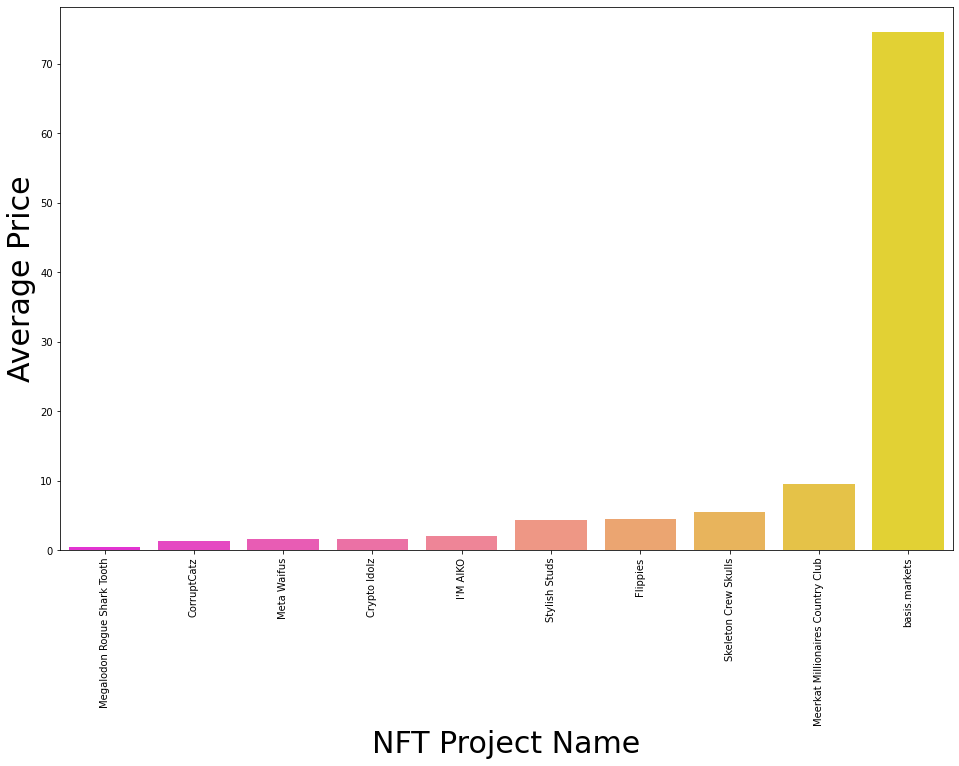

,Index,Name,Volume,Market_Cap,Sales,Floor_Price,Average_Price,Owners,Assets,Owner_Asset_Ratio
7,7,Megalodon Rogue Shark Tooth,2116.61,60.050375,5229,0.04,0.404783,946,1309,72.27
8,8,CorruptCatz,1983.92,345.790000,1489,0.10,1.332384,636,916,69.43
9,9,Meta Waifus,1844.59,989.491267,1156,1.27,1.595666,376,643,58.48
6,6,Crypto Idolz,2315.74,1168.041981,1418,0.60,1.633103,244,529,46.12
5,5,I'M AIKO,2904.70,2530.877143,1411,1.20,2.058611,599,1206,49.67
4,4,Stylish Studs,3191.15,165.000000,729,4.30,4.377435,28,50,56.00
2,2,Flippies,6732.19,1663.863158,1504,0.80,4.476190,905,1638,55.25
1,1,Skeleton Crew Skulls,11381.25,106.656000,2075,0.67,5.484940,103,132,78.03
3,3,Meerkat Millionaires Country Club,3734.76,90.275000,395,3.79,9.455089,19,23,82.61
0,0,basis.markets,27256.63,708.145455,366,39.50,74.471667,12,16,75.00


In [18]:
top_avg = nft.head(10).sort_values(by='Average_Price')
plt.subplots(figsize=(16,10))
sns.barplot(x=top_avg.Name, y=top_avg.Average_Price, palette='spring')
plt.xticks(rotation=90)
plt.ylabel("Average Price", fontsize=30)
plt.xlabel("NFT Project Name", fontsize=30)
plt.show()

display(nft.head(10).sort_values(by='Average_Price', ascending=True))


,Index,Volume,Market_Cap,Sales,Floor_Price,Average_Price,Owners,Assets,Owner_Asset_Ratio
Index,1.000000,-0.234445,-0.331022,-0.416273,-0.033973,-0.208543,-0.315575,-0.320982,-0.180560
Volume,-0.234445,1.000000,0.356271,0.238439,0.069615,0.605738,0.144694,0.126606,0.066704
Market_Cap,-0.331022,0.356271,1.000000,0.400295,-0.009540,0.110256,0.414119,0.535009,-0.094358
Sales,-0.416273,0.238439,0.400295,1.000000,-0.034665,-0.034781,0.810149,0.751806,0.028560
Floor_Price,-0.033973,0.069615,-0.009540,-0.034665,1.000000,0.207361,-0.044679,-0.052571,0.092825
Average_Price,-0.208543,0.605738,0.110256,-0.034781,0.207361,1.000000,-0.069190,-0.084522,0.086463
Owners,-0.315575,0.144694,0.414119,0.810149,-0.044679,-0.069190,1.000000,0.908035,0.045991
Assets,-0.320982,0.126606,0.535009,0.751806,-0.052571,-0.084522,0.908035,1.000000,-0.146190
Owner_Asset_Ratio,-0.180560,0.066704,-0.094358,0.028560,0.092825,0.086463,0.045991,-0.146190,1.000000


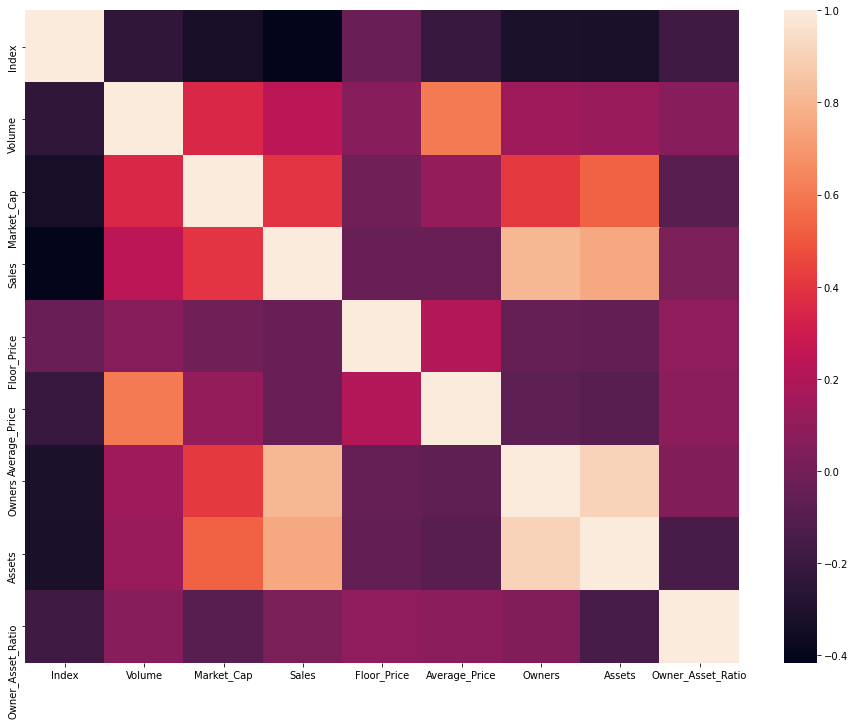

In [19]:
nft.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(nft.corr(), cmap="rocket")
nft.corr()

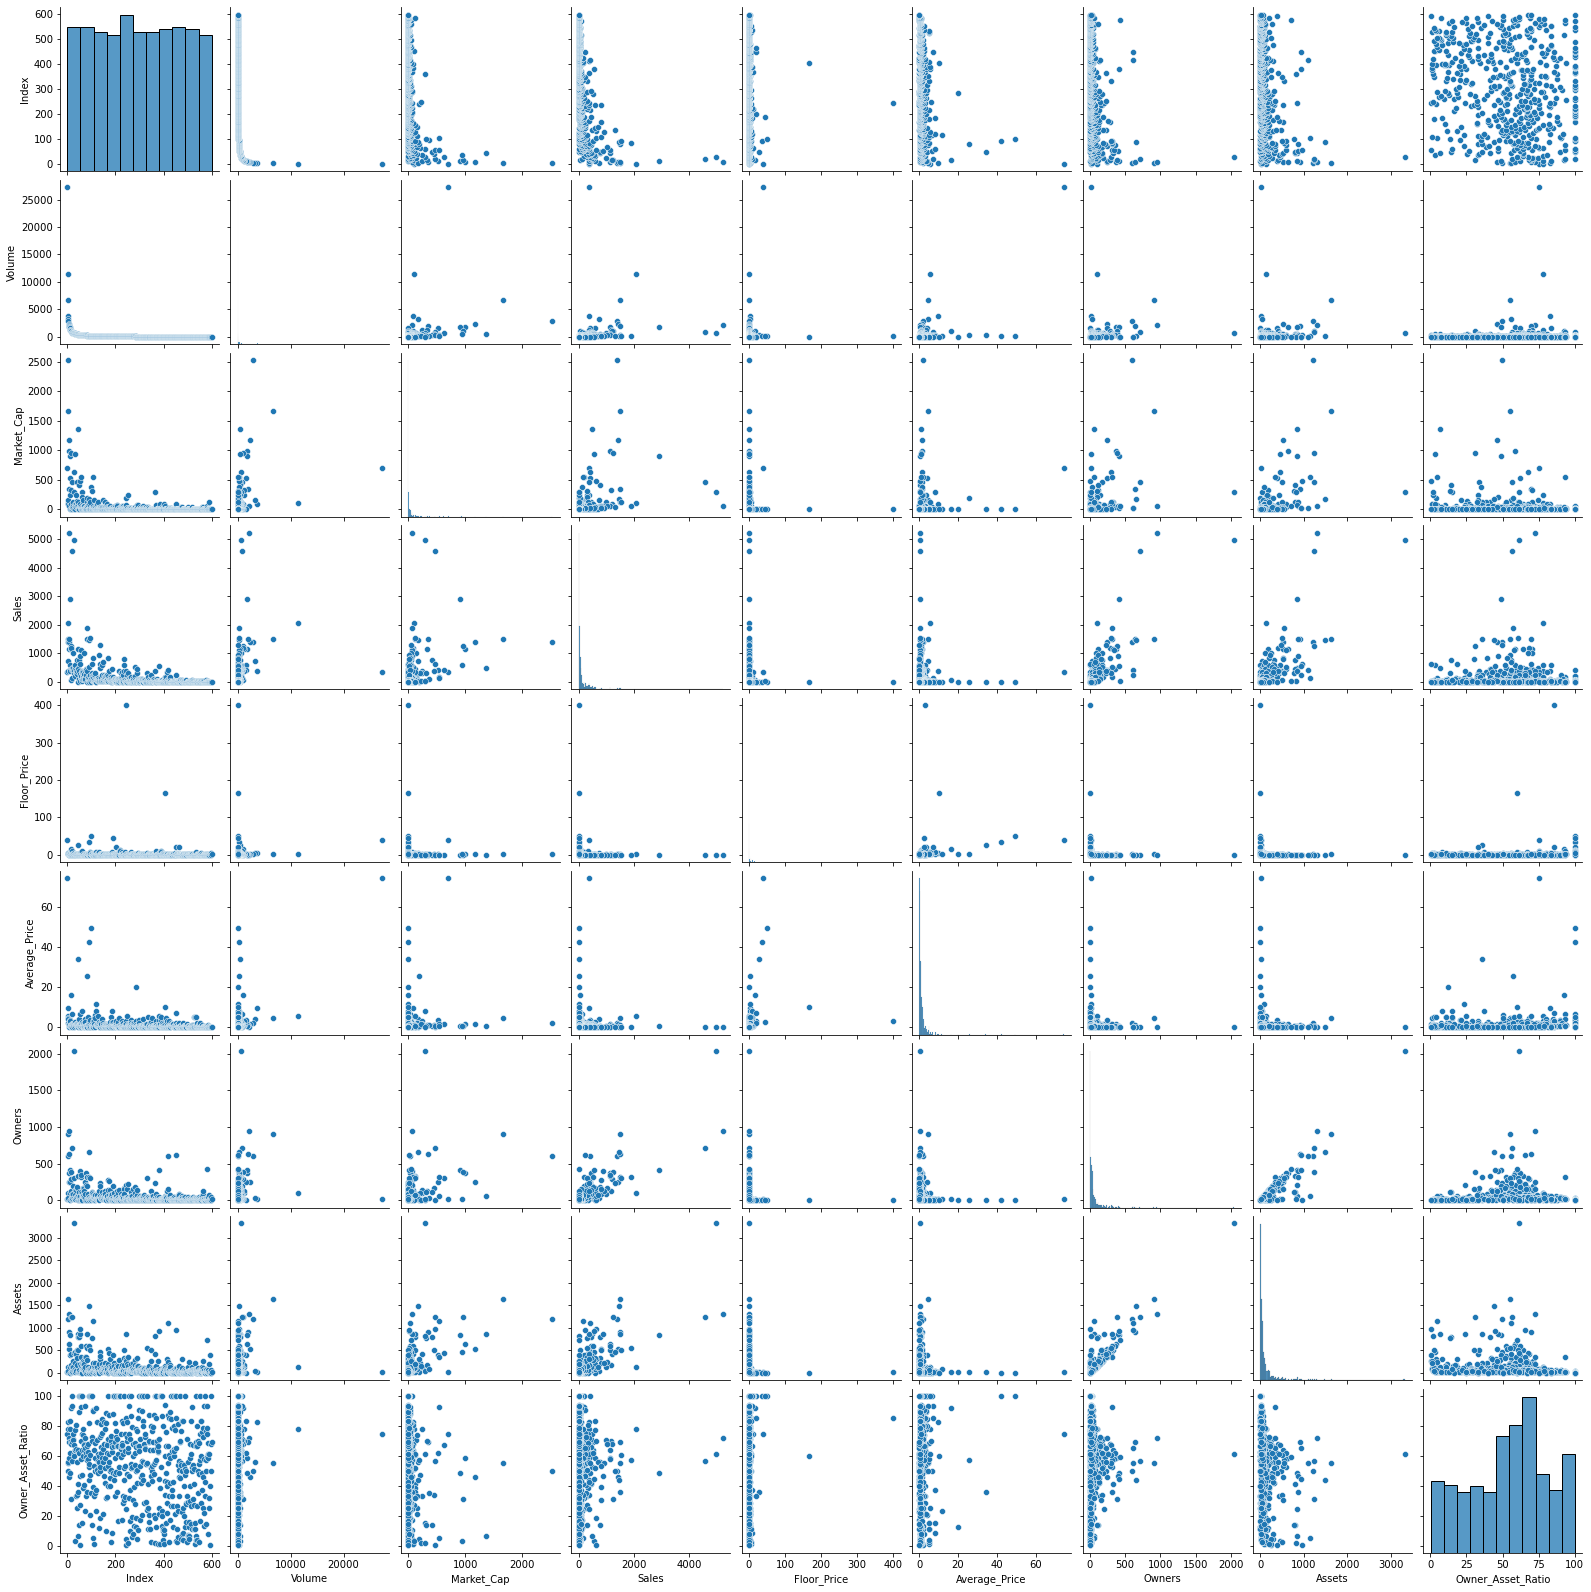

In [20]:
sns.pairplot(nft)
plt.show()

#### Feature: Assets and Owner

Text(0, 0.5, 'Assets')

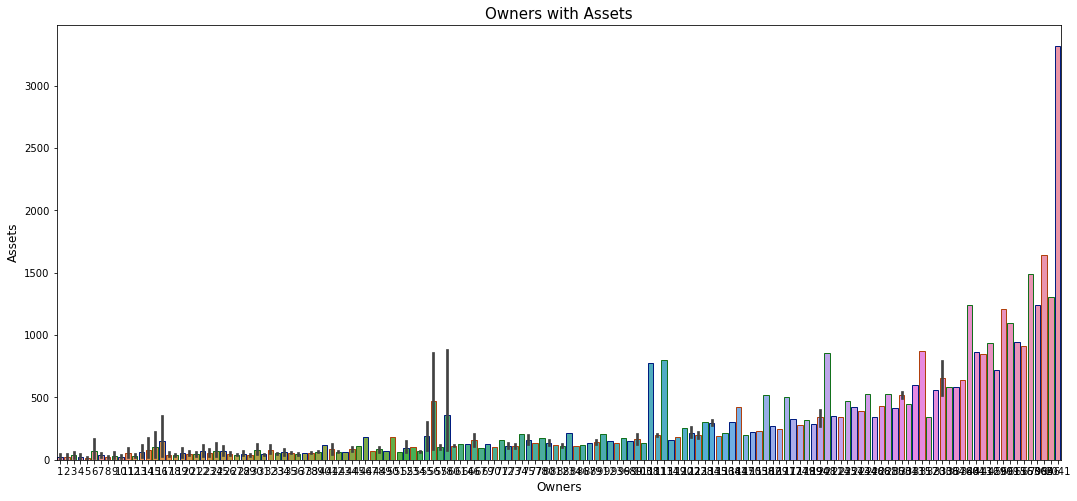

In [21]:
# nft_assets = nft.groupby(['Owner'])['Assets'].mean().reset_index()

plt.figure(figsize=(18,8))
sns.barplot(x = "Owners",y="Assets",data = nft,
            edgecolor=sns.color_palette("dark", 3))
plt.title('Owners with Assets', fontsize=15)
plt.xlabel('Owners', fontsize=12)
plt.ylabel('Assets', fontsize=12)

#### Feature: Sales and Owners

Text(0, 0.5, 'Assets')

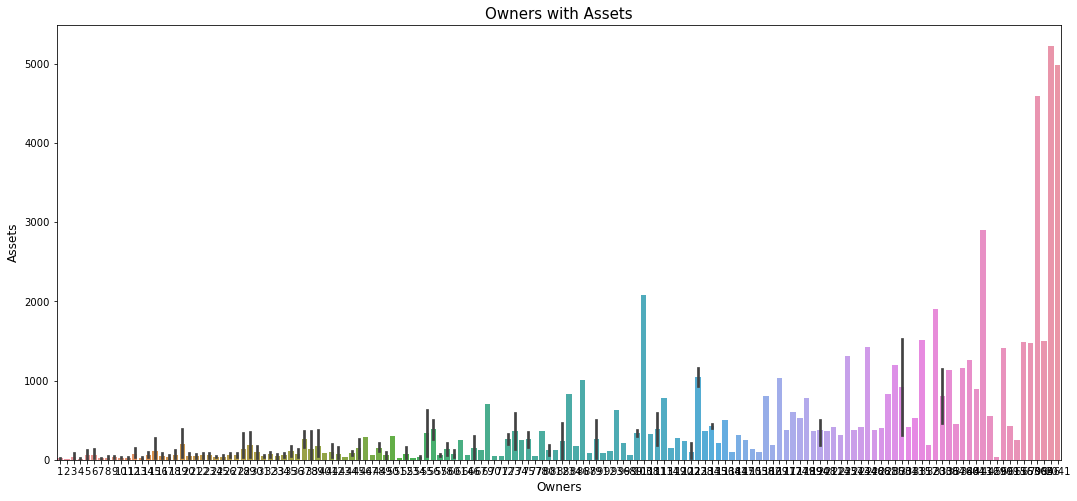

In [22]:
plt.figure(figsize=(18,8))
sns.barplot(x = "Owners",y="Sales",data = nft)
plt.title('Owners with Assets', fontsize=15)
plt.xlabel('Owners', fontsize=12)
plt.ylabel('Assets', fontsize=12)

## Trainning Model

#### Data Preprocessing

In [23]:
##transforming data so that it fits within a specific scale
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_scaler = nft[['Owners','Assets','Market_Cap','Sales']]
df_scaler = pd.DataFrame(scaler.fit_transform(df_scaler), columns=df_scaler.columns)
df_scaler.head()

,Owners,Assets,Market_Cap,Sales
0,0.005392,0.004519,0.279802,0.069994
1,0.050000,0.039470,0.042142,0.396825
2,0.443137,0.493221,0.657425,0.287627
3,0.008824,0.006629,0.035669,0.075540
4,0.013235,0.014763,0.065195,0.139415


In [24]:
## select columns feature to create the model
from sklearn.model_selection import train_test_split
x = df_scaler[['Market_Cap','Owners','Assets']]
y = df_scaler['Sales']

## split data for train and test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=1)

#### Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
lr = LinearRegression().fit(x_train, y_train)

y_pred = lr.predict(x_test)

lr_score = r2_score(y_test, y_pred)
lr_rmse = mean_squared_error(y_test, y_pred, squared = False)
print("R2 Score : ", lr_score)
print("RMSE : ", lr_rmse)


R2 Score :  0.5910089886966423
RMSE :  0.05093097161528904


#### RandomForest Regression

In [26]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor().fit(x_train, y_train)

y_pred = rfr.predict(x_test)
rfr_score = r2_score(y_test, y_pred)
rfr_rmse = mean_squared_error(y_test, y_pred, squared = False)
print("R2 Score : ", rfr_score)
print("RMSE : ", rfr_rmse)

R2 Score :  0.585138969644907
RMSE :  0.05129516138119281
